# B-spline MLEM unfolding method (`unfold_mlem_bs`)

Implementation of the MLEM-BS algorithm of

> V. Mazankova, L. Torokova, D. Trunec, Z. Kopecky, Z. Matej,
> *Experimental Measurement of Neutron Flux and Its Mathematical Data Processing*,
> **Proceedings of the 5th International Conference CNDGS'2026**, Brno, Czech Republic,
> 7–10 September 2026, https://doi.org/10.47459/cndcgs.2026.61.

The measurements are described by the discrete Fredholm equation of the first kind
with Poisson counts

$$n_i = \sum_j R_{ij}\, x_j, \qquad i = 1,\dots,I.$$

Instead of solving for the bin values $x_j$ directly, the paper represents the
spectrum in a **B-spline basis**

$$x(E) = \sum_{s=1}^{N_s} b_s\, B_s(E), \qquad \widetilde{R} = R\,B,$$

and finds the non-negative coefficients $b_s$ with the **regularized MLEM
iteration** (Eq. 4 of the paper):

$$b_s^{(k+1)} = \frac{b_s^{(k)}}{\sum_i (RB)_{is} + \beta\, \partial P/\partial b_s}
\sum_i (RB)_{is}\, \frac{n_i}{\sum_{s'} (RB)_{is'}\, b_{s'}^{(k)}},$$

with the second-derivative penalty (Eq. 5) $P(b) = \|D^{(2)} b\|_2^2$ and the
**B-spline sieve** (non-negative coefficients, Szkutnik 2005). The number of
iterations, $N_s$ and $\beta$ are selected by minimizing the goodness-of-fit
statistic (Eq. 6)

$$K_S = \left| \frac{\sum_i (n_i - m_i)^2}{\sum_i m_i} - 1 \right|,$$

and confidence intervals are estimated with a **Poisson bootstrap** (Eqs. 7–9).

## Synthetic benchmark: AmBe-like spectrum

We unfold a known AmBe-like spectrum (evaporation body + 4.5 MeV cascade bump +
thermal tail) from Poisson-noisy Bonner sphere readings of the default GSF
response set, and compare MLEM-BS with the plain MLEM baseline.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from bssunfold import Detector

detector = Detector()
E = detector.E_MeV

f_true = (
    0.55 * np.sqrt(E / 2.0) * np.exp(-E / 2.0)     # evaporation-like body
    + 0.20 * np.exp(-((E - 4.5) / 1.2) ** 2)       # cascade bump
    + 0.02 / (1.0 + (E / 0.05) ** 2)               # thermal / epithermal tail
)
f_true *= 1e6 / f_true.max()

A = np.array([detector.sensitivities[n] for n in detector.detector_names])
readings_exact = A @ f_true
readings_noisy = np.random.default_rng(42).poisson(readings_exact * 100) / 100.0
readings = {n: float(v) for n, v in zip(detector.detector_names, readings_noisy)}
print(f"{detector.n_energy_bins} energy bins, {detector.n_detectors} spheres")
print("noisy readings:", {k: round(v, 3) for k, v in readings.items()})

60 energy bins, 10 spheres
noisy readings: {'0in': 95974.53, '2in': 271020.67, '3in': 589835.3, '5in': 981842.1, '6in': 965762.05, '8in': 748450.3, '10in': 505588.14, '12in': 324880.08, '15in': 172440.76, '18in': 88527.95}


## Unfold: MLEM-BS vs plain MLEM

The B-spline sieve restricts the solution to $N_s \ll n$ smooth basis functions,
so the Poisson noise that plain MLEM amplifies on this ill-conditioned system is
strongly suppressed.

In [2]:
res_mlem = detector.unfold_mlem(readings, max_iterations=300)
res_bs = detector.unfold_mlem_bs(readings, max_iterations=500)

print(f"MLEM-BS: method={res_bs['method']}, N_s={res_bs['n_basis']}, "
      f"iterations={res_bs['iterations']}, K_S={res_bs['ks_final']:.4g}, "
      f"beta_eff={res_bs['beta_effective']:.3g}")

tv = lambda x: np.linalg.norm(np.diff(x, 2))
print(f"smoothness ||D2 x||:  MLEM={tv(res_mlem['spectrum']):.4g}  "
      f"MLEM-BS={tv(res_bs['spectrum']):.4g}  "
      f"(ratio {tv(res_mlem['spectrum']) / tv(res_bs['spectrum']):.0f}x)")

MLEM-BS: method=MLEM-BS, N_s=30, iterations=500, K_S=3.35, beta_eff=0
smoothness ||D2 x||:  MLEM=7.966e+06  MLEM-BS=2.355e+05  (ratio 34x)


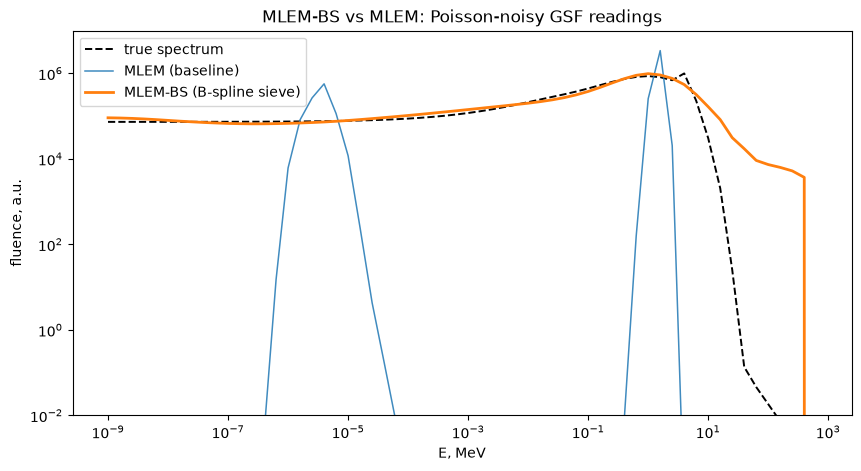

In [3]:
fig, ax = plt.subplots(figsize=(8.5, 4.6), constrained_layout=True)
ax.loglog(E, f_true, "k--", lw=1.4, label="true spectrum")
ax.loglog(E, res_mlem["spectrum"], lw=1.1, alpha=0.85, label="MLEM (baseline)")
ax.loglog(E, res_bs["spectrum"], lw=2.0, label="MLEM-BS (B-spline sieve)")
ax.set_ylim(1e-2, 1e7)
ax.set_xlabel("E, MeV")
ax.set_ylabel("fluence, a.u.")
ax.set_title("MLEM-BS vs MLEM: Poisson-noisy GSF readings")
ax.legend()
plt.show()

## Poisson bootstrap confidence intervals (Eqs. 7–9)

The backward-reconstructed counts $n^{(0)} = R x^{(0)}$ are resampled as Poisson
replicates; each replicate is unfolded and the percentile interval is formed from
the $\alpha/2$ and $1-\alpha/2$ quantiles (95% CI for $\alpha = 0.05$).

95% CI arrays: (60,) (60,)


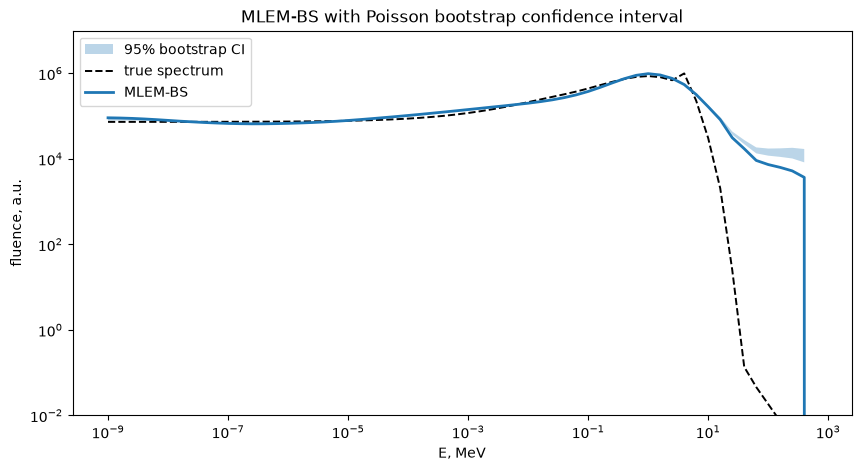

In [4]:
res_ci = detector.unfold_mlem_bs(
    readings, max_iterations=500,
    bootstrap_ci=True, n_bootstrap=100, random_state=42,
)
print("95% CI arrays:", res_ci["ci_low"].shape, res_ci["ci_high"].shape)

fig, ax = plt.subplots(figsize=(8.5, 4.6), constrained_layout=True)
ax.fill_between(E, res_ci["ci_low"], res_ci["ci_high"], alpha=0.30,
                label="95% bootstrap CI")
ax.loglog(E, f_true, "k--", lw=1.4, label="true spectrum")
ax.loglog(E, res_ci["spectrum"], lw=2.0, label="MLEM-BS")
ax.set_ylim(1e-2, 1e7)
ax.set_xlabel("E, MeV")
ax.set_ylabel("fluence, a.u.")
ax.set_title("MLEM-BS with Poisson bootstrap confidence interval")
ax.legend()
plt.show()

## Automatic parameter selection (`auto_params=True`)

Following the paper, the iteration count, the B-spline dimension $N_s$ and the
penalty strength $\beta$ can be selected by minimizing the $K_S$ statistic over a
candidate grid. $K_S \approx 0$ means residuals consistent with Poisson noise.

In [5]:
res_auto = detector.unfold_mlem_bs(readings, max_iterations=600, auto_params=True)

table = res_auto["auto_selection"]["candidates"]
print(f"{len(table)} candidates scanned; top 5 by K_S:")
for c in sorted(table, key=lambda c: c["ks"])[:5]:
    print(f"  N_s={c['n_basis']:>3}  beta_rel={c['beta_relative']:<8g} "
          f"iters={c['iterations']:>4}  K_S={c['ks']:.4g}")

chosen = res_auto["auto_selection"]["chosen"]
print(f"\nchosen: N_s={chosen['n_basis']}, beta_rel={chosen['beta_relative']}, "
      f"K_S={chosen['ks']:.4g} @ iteration {chosen['ks_iteration']}")

40 candidates scanned; top 5 by K_S:
  N_s= 60  beta_rel=0        iters= 272  K_S=2.716
  N_s= 45  beta_rel=0        iters= 299  K_S=2.794
  N_s= 34  beta_rel=0        iters= 367  K_S=3.195
  N_s= 25  beta_rel=0        iters= 400  K_S=4.987
  N_s= 19  beta_rel=0        iters= 400  K_S=10.89

chosen: N_s=60, beta_rel=0.0, K_S=2.716 @ iteration 222


## Notes

* The absolute penalty $\beta$ of the paper (`1.0e-17`) is problem-scale
  dependent; here the scale-free `beta_relative` (relative to the mean MLEM
  sensitivity) is also accepted, and the default `beta=0` already regularizes
  through the sieve + small $N_s$.
* The count-resampling bootstrap captures the **statistical** (Poisson)
  uncertainty. On strongly underdetermined BSS systems (few spheres, many bins)
  systematic model bias dominates and the intervals become optimistic — prefer
  smaller $N_s$, `auto_params=True` or an informative `initial_spectrum` there.
* Diagnostics returned by the method: `ks_history`, `ks_final`, `chi2_pearson`,
  `n_basis`, `interior_knots`, `beta_effective`, `coefficients`
  (non-negative B-spline coefficients) and, with `auto_params=True`,
  `auto_selection` with the full candidate table.